Task A. Data Processing and Graph Construction

In [1]:
%pip install matplotlib networkx pandas numpy scikit-learn scipy jupyter ipykernel

  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached jupyter-1.1.1-py2.py3-none-any.whl (2.7 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached jupyter_console-6.6.3-py3-none-any.whl (24 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [jupyter]

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib
print(matplotlib.__version__)

3.10.5


In [3]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [4]:
import networkx as nx
import math
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_graph(edge_file):
    return nx.read_edgelist(edge_file, nodetype=int)

def canonical_edge(u, v):
    return (u, v) if u <= v else (v, u)

def shortest_path_feature(G, u, v, max_distance=4):
    try:
        dist = nx.shortest_path_length(G, u, v)
        if 0 < dist <= max_distance:
            return 1 / dist
        return 0
    except nx.NetworkXNoPath:
        return 0

def compute_features(G, u, v):
    common_neighbors = list(nx.common_neighbors(G, u, v))
    common_neighbors_count = len(common_neighbors)

    union = len(set(G.neighbors(u)).union(G.neighbors(v)))
    jaccard = common_neighbors_count / union if union != 0 else 0.0

    adamic_adar = sum(
        1 / math.log(G.degree(w))
        for w in common_neighbors
        if G.degree(w) > 1
    )

    resource_allocation = sum(
        1 / G.degree(w)
        for w in common_neighbors
        if G.degree(w) > 0
    )

    preferential_attachment = G.degree(u) * G.degree(v)

    return [
        common_neighbors_count,
        jaccard,
        adamic_adar,
        resource_allocation,
        preferential_attachment,
    ]

G_train = load_graph('../ASTRO-PH/CA-AstroPh-train.txt')
print("Train nodes:", G_train.number_of_nodes())
print("Train edges:", G_train.number_of_edges())


Train nodes: 18616
Train edges: 178443


In [5]:
G_test = load_graph('../ASTRO-PH/CA-AstroPh-test.txt')
print("Test nodes:", G_test.number_of_nodes())
print("Test edges:", G_test.number_of_edges())

Test nodes: 11517
Test edges: 19667


In [6]:
# Treat all edges as undirected.
G_train = G_train.to_undirected()
G_test = G_test.to_undirected()

In [7]:
# Remove self-loops.
print("Removed self-loops in train set:", len(list(nx.selfloop_edges(G_train))))
print("Removed self-loops in test set:", len(list(nx.selfloop_edges(G_test))))
G_train.remove_edges_from(nx.selfloop_edges(G_train))
G_test.remove_edges_from(nx.selfloop_edges(G_test))

Removed self-loops in train set: 56
Removed self-loops in test set: 4


In [8]:
# Canonical edge sets for safe overlap/future-edge comparison on an undirected graph.
train_edges = {canonical_edge(u, v) for u, v in G_train.edges()}
test_edges = {canonical_edge(u, v) for u, v in G_test.edges()}

overlap_edges = train_edges & test_edges
print("Number of overlapping edges:", len(overlap_edges))

Number of overlapping edges: 0


In [9]:
# Future edges: appear in test but not in train.
future_edges = test_edges - train_edges
print("Number of future edges:", len(future_edges))

# Keep only future edges whose endpoints already exist in the train graph.
train_nodes = set(G_train.nodes())
predictable_future_edges = {
    (u, v) for (u, v) in future_edges
    if u in train_nodes and v in train_nodes
}
print("Predictable future edges:", len(predictable_future_edges))
print("Unpredictable future edges:", len(future_edges) - len(predictable_future_edges))

Number of future edges: 19663
Predictable future edges: 19512
Unpredictable future edges: 151


In [10]:
print("Future edges (first 10):", list(future_edges)[:10])
print("Predictable future edges (first 10):", list(predictable_future_edges)[:10])

Future edges (first 10): [(64747, 101052), (22105, 74844), (48487, 88012), (87485, 89458), (108108, 124668), (90879, 94797), (101797, 103749), (29228, 117676), (99239, 126948), (26886, 52046)]
Predictable future edges (first 10): [(64747, 101052), (28391, 105798), (492, 10639), (22105, 74844), (79187, 101986), (64411, 131133), (39298, 127393), (6506, 36704), (83151, 111937), (48487, 88012)]


Task B. Network Analysis

,Graph,Number of Nodes,Number of Edges,Average Degree,Maximum Degree,Graph Density,Connected Components,Average Clustering Coefficient
0,Train,18616,178387,19.1649,461,0.001030,282,0.551517
1,Test,11517,19663,3.4146,49,0.000297,730,0.032197


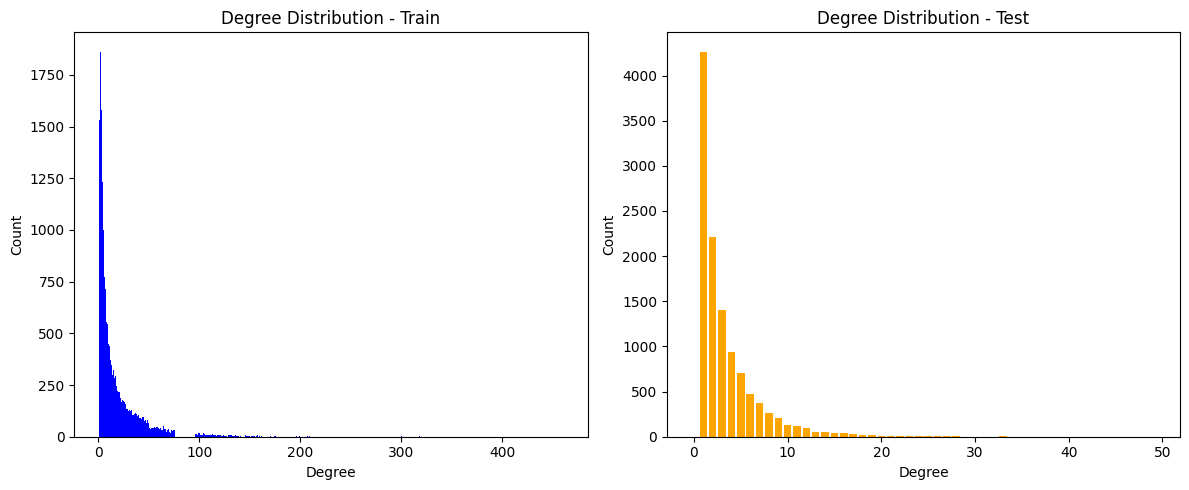

In [11]:
import pandas as pd
import networkx as nx
from IPython.display import display

def graph_statistics(G, graph_name):
    degrees = dict(G.degree())
    degree_values = list(degrees.values())
    avg_degree = sum(degree_values) / len(degree_values) if degree_values else 0
    max_degree = max(degree_values) if degree_values else 0
    density = nx.density(G)
    num_components = nx.number_connected_components(G)
    avg_clustering = nx.average_clustering(G)
    degree_distribution = pd.Series(degree_values).value_counts().sort_index()

    summary = pd.DataFrame([{
        "Graph": graph_name,
        "Number of Nodes": G.number_of_nodes(),
        "Number of Edges": G.number_of_edges(),
        "Average Degree": round(avg_degree, 4),
        "Maximum Degree": max_degree,
        "Graph Density": round(density, 6),
        "Connected Components": num_components,
        "Average Clustering Coefficient": round(avg_clustering, 6),
    }])

    distribution = degree_distribution.reset_index()
    distribution.columns = ["Degree", "Count"]

    return summary, distribution

train_summary, train_degree_distribution = graph_statistics(G_train, "Train")
test_summary, test_degree_distribution = graph_statistics(G_test, "Test")

graph_summary_table = pd.concat([train_summary, test_summary], ignore_index=True)
display(graph_summary_table)

#show the bar chart of degree distribution for train and test sets
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(train_degree_distribution["Degree"], train_degree_distribution["Count"], color='blue')
plt.title("Degree Distribution - Train")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.subplot(1, 2, 2)

plt.bar(test_degree_distribution["Degree"], test_degree_distribution["Count"], color='orange')
plt.title("Degree Distribution - Test")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [12]:
def add_samples(G, pairs, label, X, y):
    for u, v in pairs:
        features = compute_features(G, u, v)
        X.append([u, v, *features])
        y.append(label)

def create_dataset(G, num_negative=None, seed=42):
    edges = list(G.edges())
    non_edges = list(nx.non_edges(G))

    if num_negative is None:
        num_negative = len(edges)

    rng = random.Random(seed)
    non_edges = rng.sample(non_edges, num_negative)

    X = []
    y = []

    # Positive links (existing edges in the train graph)
    add_samples(G, edges, label=1, X=X, y=y)

    # Negative links (sampled non-edges in the train graph)
    add_samples(G, non_edges, label=0, X=X, y=y)

    return pd.DataFrame(X), pd.Series(y)

X, y = create_dataset(G_train)

X.columns = [
    "u",
    "v",
    "common_neighbors",
    "jaccard",
    "adamic_adar",
    "resource_allocation",
    "preferential_attachment",
]

train_data = pd.concat([X, y.rename("label")], axis=1)
train_data.to_csv("train_data.csv", index=False)
print("Saved train_data.csv with shape:", train_data.shape)

Saved train_data.csv with shape: (356774, 8)


Task B.1 Main Topic 3 Baseline Link Prediction

This block keeps the direct temporal link prediction pipeline:
- positive candidates = predictable future edges
- negative candidates = sampled non-edges / hard negatives
- evaluation = Top-K, Precision@K, Recall@K


In [13]:
def sample_negative_edges(G, forbidden_edges, num_samples, seed=42):
    rng = random.Random(seed)
    nodes = list(G.nodes())
    negative_edges = set()

    while len(negative_edges) < num_samples:
        u, v = rng.sample(nodes, 2)
        edge = canonical_edge(u, v)

        if edge in forbidden_edges:
            continue
        if G.has_edge(u, v):
            continue

        negative_edges.add(edge)

    return negative_edges

def sample_hard_negative_edges(G, forbidden_edges, num_samples, seed=42):
    rng = random.Random(seed)
    nodes = list(G.nodes())
    hard_negatives = set()

    while len(hard_negatives) < num_samples:
        u, v = rng.sample(nodes, 2)
        edge = canonical_edge(u, v)

        if edge in forbidden_edges:
            continue
        if G.has_edge(u, v):
            continue
        if len(list(nx.common_neighbors(G, u, v))) == 0:
            continue

        hard_negatives.add(edge)

    return hard_negatives

forbidden_edges = train_edges | predictable_future_edges
negative_candidate_edges = sample_negative_edges(
    G_train,
    forbidden_edges=forbidden_edges,
    num_samples=len(predictable_future_edges),
    seed=42,
)

hard_negative_edges = sample_hard_negative_edges(
    G_train,
    forbidden_edges=forbidden_edges,
    num_samples=len(predictable_future_edges),
    seed=42,
)

print("Predictable future edges:", len(predictable_future_edges))
print("Random negative candidates:", len(negative_candidate_edges))
print("Hard negative candidates:", len(hard_negative_edges))

Predictable future edges: 19512
Random negative candidates: 19512
Hard negative candidates: 19512


In [14]:
def score_common_neighbors(G, u, v):
    return len(list(nx.common_neighbors(G, u, v)))

def score_jaccard(G, u, v):
    neighbors_u = set(G.neighbors(u))
    neighbors_v = set(G.neighbors(v))
    union_size = len(neighbors_u | neighbors_v)
    if union_size == 0:
        return 0.0
    return len(neighbors_u & neighbors_v) / union_size

def score_adamic_adar(G, u, v):
    score = 0.0
    for w in nx.common_neighbors(G, u, v):
        deg = G.degree(w)
        if deg > 1:
            score += 1 / math.log(deg)
    return score

def score_resource_allocation(G, u, v):
    score = 0.0
    for w in nx.common_neighbors(G, u, v):
        deg = G.degree(w)
        if deg > 0:
            score += 1 / deg
    return score

def score_preferential_attachment(G, u, v):
    return G.degree(u) * G.degree(v)

def compute_baseline_scores(G, candidate_edges, labels_dict):
    rows = []
    for u, v in candidate_edges:
        edge = canonical_edge(u, v)
        rows.append({
            "u": u,
            "v": v,
            "edge": edge,
            "label": labels_dict[edge],
            "common_neighbors": score_common_neighbors(G, u, v),
            "jaccard": score_jaccard(G, u, v),
            "adamic_adar": score_adamic_adar(G, u, v),
            "resource_allocation": score_resource_allocation(G, u, v),
            "preferential_attachment": score_preferential_attachment(G, u, v),
        })
    return pd.DataFrame(rows)

candidate_edges = list(predictable_future_edges) + list(negative_candidate_edges)
candidate_labels = {edge: 1 for edge in predictable_future_edges}
candidate_labels.update({edge: 0 for edge in negative_candidate_edges})
baseline_df = compute_baseline_scores(G_train, candidate_edges, candidate_labels)

hard_candidate_edges = list(predictable_future_edges) + list(hard_negative_edges)
hard_candidate_labels = {edge: 1 for edge in predictable_future_edges}
hard_candidate_labels.update({edge: 0 for edge in hard_negative_edges})
hard_baseline_df = compute_baseline_scores(G_train, hard_candidate_edges, hard_candidate_labels)

print("Baseline score table shape:", baseline_df.shape)
print("Hard baseline score table shape:", hard_baseline_df.shape)
baseline_df.head()

Baseline score table shape: (39024, 9)
Hard baseline score table shape: (39024, 9)


,u,v,edge,label,common_neighbors,jaccard,adamic_adar,resource_allocation,preferential_attachment
0,64747,101052,"(64747, 101052)",1,9,0.236842,2.386878,0.238435,420
1,28391,105798,"(28391, 105798)",1,1,0.076923,0.455120,0.111111,13
2,492,10639,"(492, 10639)",1,10,0.068966,2.473142,0.210771,5076
3,22105,74844,"(22105, 74844)",1,1,0.022222,0.233827,0.013889,45
4,79187,101986,"(79187, 101986)",1,3,0.028302,0.806667,0.079884,2760


In [15]:
def evaluate_ranking(df, score_column, k_values, method_name=None):
    results = []
    ranked_df = df.sort_values(by=score_column, ascending=False).reset_index(drop=True)
    total_positive = int(df["label"].sum())

    for k in k_values:
        top_k = ranked_df.head(k)
        hits = int(top_k["label"].sum())
        precision_at_k = hits / k if k > 0 else 0.0
        recall_at_k = hits / total_positive if total_positive > 0 else 0.0

        results.append({
            "Method": method_name or score_column,
            "K": k,
            "Hits": hits,
            "Precision@K": precision_at_k,
            "Recall@K": recall_at_k,
        })
    return pd.DataFrame(results)

k_values = [10, 20, 50, 100]
baseline_methods = [
    "common_neighbors",
    "jaccard",
    "adamic_adar",
    "resource_allocation",
    "preferential_attachment",
]
method_name_map = {
    "common_neighbors": "Common Neighbors",
    "jaccard": "Jaccard",
    "adamic_adar": "Adamic/Adar",
    "resource_allocation": "Resource Allocation",
    "preferential_attachment": "Preferential Attachment",
}

ranking_results = pd.concat(
    [
        evaluate_ranking(
            baseline_df,
            score_column=method,
            k_values=k_values,
            method_name=method_name_map[method],
        )
        for method in baseline_methods
    ],
    ignore_index=True,
)

hard_ranking_results = pd.concat(
    [
        evaluate_ranking(
            hard_baseline_df,
            score_column=method,
            k_values=k_values,
            method_name=method_name_map[method],
        )
        for method in baseline_methods
    ],
    ignore_index=True,
)

print("Easy candidate setting:")
display(ranking_results)
print("Hard candidate setting:")
display(hard_ranking_results)

Easy candidate setting:


,Method,K,Hits,Precision@K,Recall@K
0,Common Neighbors,10,10,1.00,0.000513
1,Common Neighbors,20,20,1.00,0.001025
2,Common Neighbors,50,50,1.00,0.002563
3,Common Neighbors,100,100,1.00,0.005125
4,Jaccard,10,10,1.00,0.000513
5,Jaccard,20,20,1.00,0.001025
6,Jaccard,50,50,1.00,0.002563
7,Jaccard,100,100,1.00,0.005125
8,Adamic/Adar,10,10,1.00,0.000513
9,Adamic/Adar,20,20,1.00,0.001025


Hard candidate setting:


,Method,K,Hits,Precision@K,Recall@K
0,Common Neighbors,10,10,1.00,0.000513
1,Common Neighbors,20,20,1.00,0.001025
2,Common Neighbors,50,50,1.00,0.002563
3,Common Neighbors,100,100,1.00,0.005125
4,Jaccard,10,10,1.00,0.000513
5,Jaccard,20,19,0.95,0.000974
6,Jaccard,50,49,0.98,0.002511
7,Jaccard,100,98,0.98,0.005023
8,Adamic/Adar,10,10,1.00,0.000513
9,Adamic/Adar,20,20,1.00,0.001025


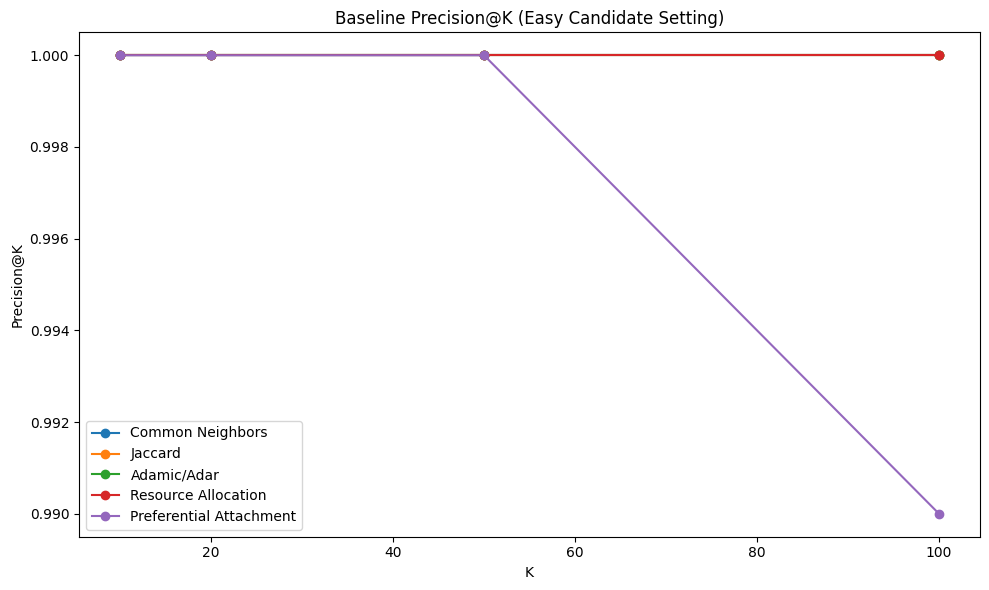

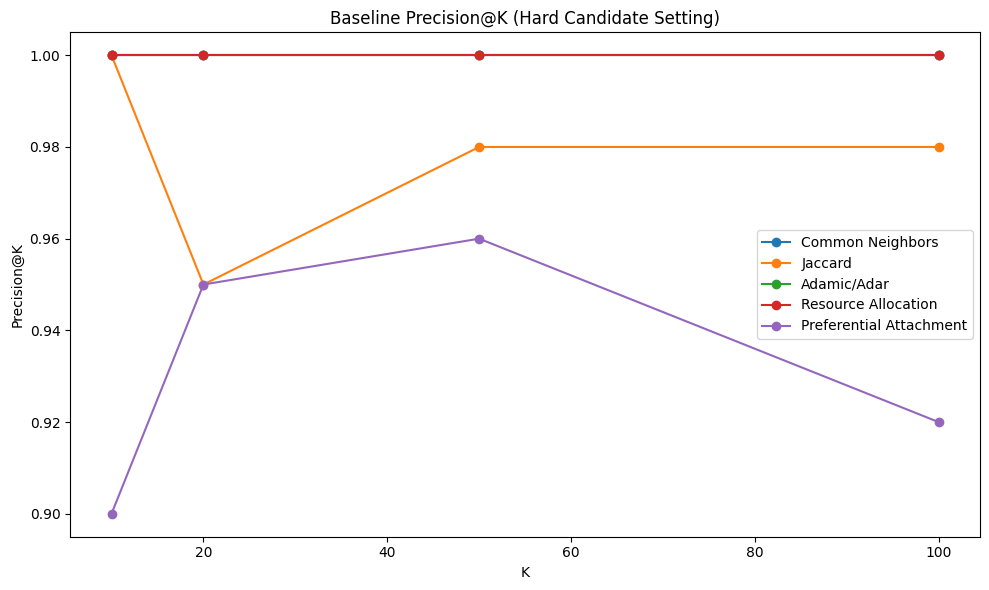

In [16]:
plt.figure(figsize=(10, 6))
for method in ranking_results["Method"].unique():
    subset = ranking_results[ranking_results["Method"] == method]
    plt.plot(subset["K"], subset["Precision@K"], marker="o", label=method)
plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Baseline Precision@K (Easy Candidate Setting)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
for method in hard_ranking_results["Method"].unique():
    subset = hard_ranking_results[hard_ranking_results["Method"] == method]
    plt.plot(subset["K"], subset["Precision@K"], marker="o", label=method)
plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Baseline Precision@K (Hard Candidate Setting)")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
import numpy as np
from scipy.optimize import fmin_l_bfgs_b


class SupervisedRandomWalk:
    def __init__(self, alpha=0.15, b=0.1, reg_lambda=1.0, max_iter=200, tol=1e-10):
        self.alpha = float(alpha)
        self.b = float(b)
        self.reg_lambda = float(reg_lambda)
        self.max_iter = int(max_iter)
        self.tol = float(tol)
        self.w = None
        self.opt_info = None

    @staticmethod
    def _sigmoid(x):
        x = np.clip(x, -50.0, 50.0)
        return 1.0 / (1.0 + np.exp(-x))

    def _validate_inputs(self, G_features, source_idx):
        if G_features.ndim != 3:
            raise ValueError("G_features must have shape (n_nodes, n_nodes, n_features).")

        n, m, k = G_features.shape
        if n != m:
            raise ValueError("G_features must be square on the first two axes.")
        if k == 0:
            raise ValueError("G_features must contain at least one feature per edge.")
        if not (0 <= source_idx < n):
            raise ValueError("source_idx is out of range.")

    def _compute_transition_matrix(self, G_features, w, source_idx):
        n = G_features.shape[0]
        edge_mask = np.any(np.abs(G_features) > 0, axis=2)

        logits = np.tensordot(G_features, w, axes=([2], [0]))
        strengths = self._sigmoid(logits) * edge_mask
        d_strengths_dw = (strengths * (1.0 - strengths))[..., None] * G_features

        row_sums = strengths.sum(axis=1, keepdims=True)
        Q_prime = np.divide(
            strengths,
            row_sums,
            out=np.zeros_like(strengths),
            where=row_sums > 0,
        )

        # Dangling rows: force all probability to restart source before alpha mixing.
        dangling_rows = row_sums[:, 0] <= 0
        if np.any(dangling_rows):
            Q_prime[dangling_rows, :] = 0.0
            Q_prime[dangling_rows, source_idx] = 1.0

        dz_dw = d_strengths_dw.sum(axis=1)
        denom = row_sums[..., None] ** 2
        dQ_prime_dw = np.divide(
            d_strengths_dw * row_sums[..., None] - strengths[..., None] * dz_dw[:, None, :],
            denom,
            out=np.zeros_like(d_strengths_dw),
            where=denom > 0,
        )

        if np.any(dangling_rows):
            dQ_prime_dw[dangling_rows, :, :] = 0.0

        Q = (1.0 - self.alpha) * Q_prime
        Q[:, source_idx] += self.alpha

        dQ_dw = (1.0 - self.alpha) * np.transpose(dQ_prime_dw, (2, 0, 1))
        return Q, dQ_dw

    def algorithm_1(self, Q, dQ_dw, source_idx):
        n = Q.shape[0]
        k = dQ_dw.shape[0]

        # Start from restart distribution concentrated on the source.
        p = np.zeros(n)
        p[source_idx] = 1.0

        for _ in range(self.max_iter):
            p_new = p @ Q
            if np.linalg.norm(p_new - p, ord=1) < self.tol:
                p = p_new
                break
            p = p_new

        dp_dw = np.zeros((k, n))
        for _ in range(self.max_iter):
            dp_next = dp_dw @ Q + np.einsum("j,kjn->kn", p, dQ_dw)
            if np.linalg.norm(dp_next - dp_dw, ord=1) < self.tol:
                dp_dw = dp_next
                break
            dp_dw = dp_next

        return p, dp_dw

    def wmw_loss(self, w, G_features, source_idx, D_indices, L_indices):
        Q, dQ_dw = self._compute_transition_matrix(G_features, w, source_idx)
        p, dp_dw = self.algorithm_1(Q, dQ_dw, source_idx)

        l2 = np.dot(w, w)
        loss = self.reg_lambda * l2
        gradient = 2.0 * self.reg_lambda * w

        if len(D_indices) == 0 or len(L_indices) == 0:
            return float(loss), gradient

        for d in D_indices:
            for l in L_indices:
                diff = (p[l] - p[d]) / self.b
                sigma = self._sigmoid(diff)
                loss += sigma

                dsigma_ddiff = sigma * (1.0 - sigma)
                gradient += (dsigma_ddiff / self.b) * (dp_dw[:, l] - dp_dw[:, d])

        return float(loss), gradient

    def fit(self, G_features, source_idx, D_indices, L_indices, initial_w=None, maxfun=150):
        self._validate_inputs(G_features, source_idx)

        n_features = G_features.shape[-1]
        if initial_w is None:
            initial_w = np.zeros(n_features, dtype=float)
        else:
            initial_w = np.asarray(initial_w, dtype=float)
            if initial_w.shape != (n_features,):
                raise ValueError("initial_w must have shape (n_features,).")

        D_indices = np.asarray(D_indices, dtype=int)
        L_indices = np.asarray(L_indices, dtype=int)

        self.w, fval, info = fmin_l_bfgs_b(
            self.wmw_loss,
            initial_w,
            args=(G_features, source_idx, D_indices, L_indices),
            maxfun=maxfun,
        )

        self.opt_info = {
            "final_loss": float(fval),
            "optimizer_info": info,
        }
        return self

    def predict_scores(self, G_features, source_idx):
        if self.w is None:
            raise ValueError("Model is not fitted. Call fit(...) first.")
        self._validate_inputs(G_features, source_idx)
        Q, dQ_dw = self._compute_transition_matrix(G_features, self.w, source_idx)
        p, _ = self.algorithm_1(Q, dQ_dw, source_idx)
        return p

Task C. Supervised Random Walk End-to-End Example
This example builds edge-feature tensors on a local subgraph, trains SRW for one source node, and evaluates ranking quality on future links.

In [18]:
from sklearn.metrics import roc_auc_score, average_precision_score

# ------------------------------
# 1) Candidate graph construction
# ------------------------------
def local_subgraph_nodes(G, source, depth=2, max_nodes=120):
    visited = {source}
    frontier = {source}

    for _ in range(depth):
        next_frontier = set()
        for u in frontier:
            next_frontier.update(G.neighbors(u))

        next_frontier -= visited
        if not next_frontier:
            break

        capacity = max_nodes - len(visited)
        if capacity <= 0:
            break

        if len(next_frontier) > capacity:
            next_frontier = set(list(next_frontier)[:capacity])

        visited.update(next_frontier)
        frontier = next_frontier

    return list(visited)


def future_positive_nodes_for_source(predictable_future_edges, source_node, node_set):
    positives = set()
    for u, v in predictable_future_edges:
        if u == source_node and v in node_set:
            positives.add(v)
        elif v == source_node and u in node_set:
            positives.add(u)
    return positives


def pick_multiple_sources_with_local_positives(
    G_train,
    predictable_future_edges,
    n_sources=5,
    min_global_pos=3,
    min_local_pos=3,
    depth=2,
    max_nodes=150,
    max_candidates=300,
):
    counts = {}
    for u, v in predictable_future_edges:
        counts[u] = counts.get(u, 0) + 1
        counts[v] = counts.get(v, 0) + 1

    if not counts:
        raise ValueError("No future edges available to build supervised tasks.")

    candidates = sorted(
        [node for node, c in counts.items() if c >= min_global_pos],
        key=lambda x: counts[x],
        reverse=True,
    )

    if not candidates:
        candidates = sorted(counts.keys(), key=lambda x: counts[x], reverse=True)

    selected = []
    used = set()

    for source_node in candidates[:max_candidates]:
        if source_node in used:
            continue

        nodes = local_subgraph_nodes(G_train, source_node, depth=depth, max_nodes=max_nodes)
        positives = future_positive_nodes_for_source(
            predictable_future_edges, source_node, set(nodes)
        )

        if len(positives) >= min_local_pos:
            selected.append((source_node, nodes, positives))
            used.add(source_node)

        if len(selected) >= n_sources:
            break

    if not selected:
        raise ValueError("Could not find enough source nodes with local positive future links.")

    return selected


def build_edge_feature_tensor(G_base, nodes):
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    n = len(nodes)
    k = 6  # [bias, common_neighbors, jaccard, adamic_adar, resource_allocation, pref_attachment]
    G_features = np.zeros((n, n, k), dtype=float)

    for u, v in G_base.subgraph(nodes).edges():
        i = node_to_idx[u]
        j = node_to_idx[v]
        common, jaccard, adamic, ra, pref = compute_features(G_base, u, v)
        feat = np.array([1.0, common, jaccard, adamic, ra, pref], dtype=float)
        G_features[i, j] = feat
        G_features[j, i] = feat

    return G_features, node_to_idx


def build_train_eval_indices(G_train, source_node, nodes, node_to_idx, positives, max_neg=80):
    train_neighbors = set(G_train.neighbors(source_node))

    candidate_neg = [
        node for node in nodes
        if node != source_node and node not in positives and node not in train_neighbors
    ]

    if not candidate_neg:
        raise ValueError("No negative candidates found for the selected source.")

    # Hard negatives: nodes with at least one common neighbor with source
    hard_neg = [
        node for node in candidate_neg
        if len(list(nx.common_neighbors(G_train, source_node, node))) > 0
    ]

    neg_pool = hard_neg if len(hard_neg) > 0 else candidate_neg

    rng = np.random.default_rng(42)
    neg_size = min(len(neg_pool), max_neg, max(10, len(positives) * 5))
    negatives = list(rng.choice(neg_pool, size=neg_size, replace=False))

    D_indices = np.array([node_to_idx[p] for p in positives], dtype=int)
    L_indices = np.array([node_to_idx[n] for n in negatives], dtype=int)
    return D_indices, L_indices, negatives


# ------------------------------
# 2) Multi-source SRW evaluation
# ------------------------------
selected_sources = pick_multiple_sources_with_local_positives(
    G_train,
    predictable_future_edges,
    n_sources=10,
    min_global_pos=4,
    min_local_pos=4,
    depth=2,
    max_nodes=200,
)

srw_case_results = []
srw_rankings = {}
srw_roc_cache = {}

for idx_case, (source_node, nodes, positives) in enumerate(selected_sources, start=1):
    G_features, node_to_idx = build_edge_feature_tensor(G_train, nodes)
    source_idx = node_to_idx[source_node]

    D_indices, L_indices, negatives = build_train_eval_indices(
        G_train, source_node, nodes, node_to_idx, positives
    )

    model = SupervisedRandomWalk(alpha=0.15, b=0.1, reg_lambda=0.01, max_iter=120, tol=1e-9)
    model.fit(G_features, source_idx, D_indices, L_indices, maxfun=120)

    scores = model.predict_scores(G_features, source_idx)

    train_neighbors = set(G_train.neighbors(source_node))
    eval_nodes = [
        node for node in nodes
        if node != source_node and node not in train_neighbors
    ]

    y_true = np.array([1 if node in positives else 0 for node in eval_nodes], dtype=int)
    y_score = np.array([scores[node_to_idx[node]] for node in eval_nodes], dtype=float)

    auc_val = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) > 1 else np.nan
    ap_val = average_precision_score(y_true, y_score) if len(np.unique(y_true)) > 1 else np.nan

    ranking = sorted(
        [(node, scores[node_to_idx[node]], int(node in positives)) for node in eval_nodes],
        key=lambda x: x[1],
        reverse=True,
    )

    srw_case_results.append({
        "Source Node": source_node,
        "Local Nodes": len(nodes),
        "Positives": len(positives),
        "Negatives": len(negatives),
        "AUC": auc_val,
        "Average Precision": ap_val,
    })

    srw_rankings[source_node] = ranking
    srw_roc_cache[source_node] = (y_true, y_score)

srw_results_df = pd.DataFrame(srw_case_results)
display(srw_results_df)

print("\nSRW summary:")
print(srw_results_df[["AUC", "Average Precision"]].agg(["mean", "std"]))

# Keep one representative case for downstream plots
rep_source_srw = srw_results_df.sort_values("AUC", ascending=False).iloc[0]["Source Node"]
rep_source_srw = int(rep_source_srw)
ranking = srw_rankings[rep_source_srw]
y_true, y_score = srw_roc_cache[rep_source_srw]

print(f"\nRepresentative SRW source node for plots: {rep_source_srw}")
print("Top-10 SRW recommendations: (node_id, score, is_future_link)")
for row in ranking[:10]:
    print(row)

,Source Node,Local Nodes,Positives,Negatives,AUC,Average Precision
0,63105,200,4,20,0.987676,0.684524



SRW summary:
           AUC  Average Precision
mean  0.987676           0.684524
std        NaN                NaN

Representative SRW source node for plots: 63105
Top-10 SRW recommendations: (node_id, score, is_future_link)
(127152, 0.008998927216234518, 1)
(36907, 0.007427293634996719, 0)
(129273, 0.005606278957970717, 1)
(119007, 0.004980207162749625, 0)
(94235, 0.004625235522562303, 0)
(49236, 0.004460223627953403, 1)
(67827, 0.0031906022471473337, 1)
(94329, 0.0030686531082425687, 0)
(38966, 0.002785853799833307, 0)
(16665, 0.00271052966868442, 0)


How to Improve Supervised Random Walk Results
1. Use more source nodes: train/evaluate across many source nodes and report mean AUC to reduce variance from one-node results.
2. Increase training positives: require more local future links per source (for example at least 5) before training.
3. Better negative sampling: use hard negatives (2-hop nodes or high-common-neighbor nodes) instead of only random negatives.
4. Add richer edge features: include shortest-path-based features, temporal recency, node centrality, and embedding similarity (e.g., node2vec cosine).
5. Feature scaling: normalize each feature (z-score or min-max) before optimization to stabilize gradients.
6. Hyperparameter search: tune alpha, b, reg_lambda, max_iter, and maxfun with validation splits.
7. Larger local graph: increase depth/max_nodes carefully so SRW sees more candidate nodes without making matrices too large.
8. Robust evaluation: use multiple train/validation/test temporal splits and report AUC plus Precision@k/Recall@k.
9. Early stopping and convergence checks: tighten tolerance and verify optimizer convergence flags.
10. Ensemble approach: combine SRW scores with heuristics (Adamic-Adar, Resource Allocation, Preferential Attachment) using a meta-model.

Task D. Machine Learning Models (Alternative to SRW)
This is a separate block that applies standard supervised ML classifiers for link prediction using the same local-graph setup.

In [19]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

def build_pair_features_for_source_ml(G_train, source_node, candidate_nodes):
    rows = []
    for v in candidate_nodes:
        common, jaccard, adamic, ra, pref = compute_features(G_train, source_node, v)
        rows.append([common, jaccard, adamic, ra, pref])
    return np.array(rows, dtype=float)

models_ml_template = {
    "LogisticRegression": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
        ]
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

ml_case_results = []
ml_roc_cache = {}
ml_rankings = {}

for source_node_ml, nodes_ml, positives_ml in selected_sources:
    train_neighbors_ml = set(G_train.neighbors(source_node_ml))

    candidate_nodes_ml = [
        node for node in nodes_ml
        if node != source_node_ml and node not in train_neighbors_ml
    ]

    # Harder negatives: prioritize nodes sharing common neighbors with source
    hard_candidate_nodes_ml = [
        node for node in candidate_nodes_ml
        if (node in positives_ml) or (len(list(nx.common_neighbors(G_train, source_node_ml, node))) > 0)
    ]

    if len(hard_candidate_nodes_ml) >= max(10, len(positives_ml) * 3):
        candidate_nodes_ml = hard_candidate_nodes_ml

    X_ml = build_pair_features_for_source_ml(G_train, source_node_ml, candidate_nodes_ml)
    y_ml = np.array([1 if node in positives_ml else 0 for node in candidate_nodes_ml], dtype=int)

    # Skip unusable cases
    if len(np.unique(y_ml)) < 2 or y_ml.sum() < 2:
        continue

    X_train_ml, X_test_ml, y_train_ml, y_test_ml, nodes_train_ml, nodes_test_ml = train_test_split(
        X_ml,
        y_ml,
        candidate_nodes_ml,
        test_size=0.4,
        random_state=42,
        stratify=y_ml,
        shuffle=True,
    )

    local_results = []
    fitted_models_ml = {}
    test_probs_ml = {}

    for name, clf in models_ml_template.items():
        clf.fit(X_train_ml, y_train_ml)
        y_prob_test = clf.predict_proba(X_test_ml)[:, 1]
        auc_ml = roc_auc_score(y_test_ml, y_prob_test)
        ap_ml = average_precision_score(y_test_ml, y_prob_test)
        local_results.append((name, auc_ml, ap_ml))
        fitted_models_ml[name] = clf
        test_probs_ml[name] = y_prob_test

    local_results_df = pd.DataFrame(local_results, columns=["Model", "AUC", "Average Precision"])
    best_model_name_ml = local_results_df.sort_values("AUC", ascending=False).iloc[0]["Model"]
    best_model_ml = fitted_models_ml[best_model_name_ml]
    y_prob_ml = test_probs_ml[best_model_name_ml]

    all_scores_ml = best_model_ml.predict_proba(X_ml)[:, 1]
    ranking_ml = sorted(
        [
            (node, score, int(label))
            for node, score, label in zip(candidate_nodes_ml, all_scores_ml, y_ml)
        ],
        key=lambda x: x[1],
        reverse=True,
    )

    for _, row in local_results_df.iterrows():
        ml_case_results.append({
            "Source Node": source_node_ml,
            "Model": row["Model"],
            "AUC": row["AUC"],
            "Average Precision": row["Average Precision"],
            "Candidate Nodes": len(candidate_nodes_ml),
            "Positive Future Links": int(y_ml.sum()),
        })

    ml_roc_cache[source_node_ml] = {
        "best_model_name": best_model_name_ml,
        "y_test": y_test_ml,
        "y_prob": y_prob_ml,
    }
    ml_rankings[source_node_ml] = ranking_ml

ml_results_df = pd.DataFrame(ml_case_results)
display(ml_results_df)

ml_summary_df = (
    ml_results_df.groupby("Model")[["AUC", "Average Precision"]]
    .agg(["mean", "std"])
    .reset_index()
)
display(ml_summary_df)

# Keep one representative case for plots
rep_source_ml = (
    ml_results_df.sort_values("AUC", ascending=False)
    .iloc[0]["Source Node"]
)
rep_source_ml = int(rep_source_ml)
best_model_name_ml = ml_roc_cache[rep_source_ml]["best_model_name"]
y_test_ml = ml_roc_cache[rep_source_ml]["y_test"]
y_prob_ml = ml_roc_cache[rep_source_ml]["y_prob"]
ranking_ml = ml_rankings[rep_source_ml]

print(f"\nRepresentative ML source node for plots: {rep_source_ml}")
print(f"Best ML model on representative case: {best_model_name_ml}")
print("Top-10 ML recommendations: (node_id, score, is_future_link)")
for row in ranking_ml[:10]:
    print(row)


,Source Node,Model,AUC,Average Precision,Candidate Nodes,Positive Future Links
0,63105,LogisticRegression,0.982456,0.750000,146,4
1,63105,RandomForest,0.973684,0.700000,146,4
2,63105,GradientBoosting,0.750000,0.516949,146,4


Model       AUC     Average Precision    
                           mean std              mean std
0    GradientBoosting  0.750000 NaN          0.516949 NaN
1  LogisticRegression  0.982456 NaN          0.750000 NaN
2        RandomForest  0.973684 NaN          0.700000 NaN


Representative ML source node for plots: 63105
Best ML model on representative case: LogisticRegression
Top-10 ML recommendations: (node_id, score, is_future_link)
(127152, 0.9999999989754511, 1)
(129273, 0.9999324579394235, 1)
(49236, 0.963528281087545, 1)
(94329, 0.9391506611654724, 0)
(119007, 0.8637973007369538, 0)
(36907, 0.4324417949039638, 0)
(47311, 0.32772502877728127, 0)
(67827, 0.2583773419842035, 1)
(22703, 0.24671764972695226, 0)
(28704, 0.15079544191519534, 0)


SRW aggregate summary:


,AUC,Average Precision
mean,0.987676,0.684524
std,NaN,NaN



ML aggregate summary:


,AUC,Average Precision
Model,,
GradientBoosting,0.750000,0.516949
LogisticRegression,0.982456,0.750000
RandomForest,0.973684,0.700000


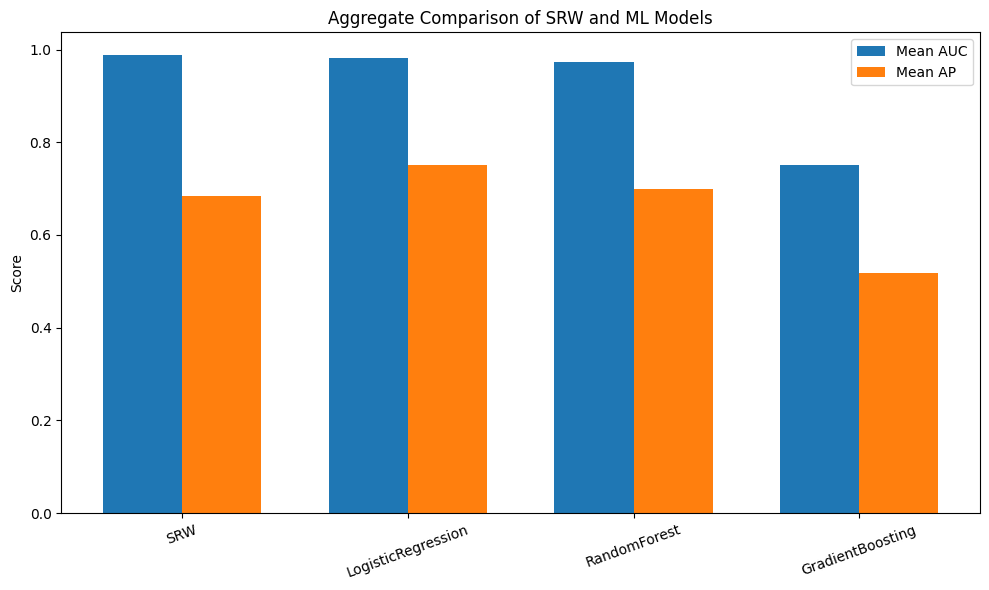

In [20]:
# Compare SRW and ML scores on the shared top recommendations.
# Compare SRW and ML aggregate performance
import matplotlib.pyplot as plt
import numpy as np

srw_summary = srw_results_df[["AUC", "Average Precision"]].agg(["mean", "std"])
ml_summary_plot = ml_results_df.groupby("Model")[["AUC", "Average Precision"]].mean()

print("SRW aggregate summary:")
display(srw_summary)

print("\nML aggregate summary:")
display(ml_summary_plot)

plot_df = ml_summary_plot.copy()
plot_df.loc["SRW"] = [
    srw_results_df["AUC"].mean(),
    srw_results_df["Average Precision"].mean(),
]

plot_df = plot_df.loc[["SRW", "LogisticRegression", "RandomForest", "GradientBoosting"]]

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, plot_df["AUC"], width=width, label="Mean AUC")
plt.bar(x + width/2, plot_df["Average Precision"], width=width, label="Mean AP")
plt.xticks(x, plot_df.index, rotation=20)
plt.ylabel("Score")
plt.title("Aggregate Comparison of SRW and ML Models")
plt.legend()
plt.tight_layout()
plt.show()


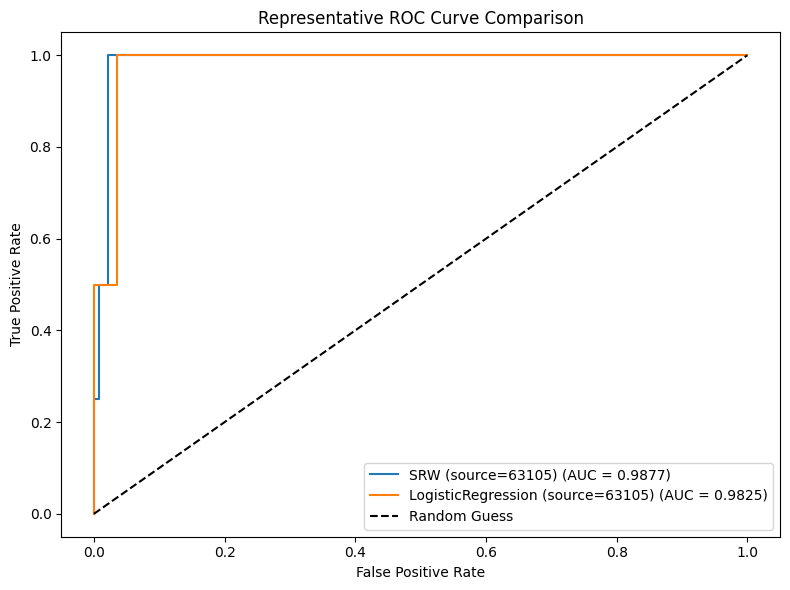

In [21]:
# Compare ROC curves on representative SRW and ML cases
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_curve(y_true, y_scores, label):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.4f})")
    return roc_auc

plt.figure(figsize=(8, 6))
auc_srw = plot_roc_curve(y_true, y_score, f"SRW (source={rep_source_srw})")
auc_ml = plot_roc_curve(y_test_ml, y_prob_ml, f"{best_model_name_ml} (source={rep_source_ml})")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Representative ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()


In [22]:
print("Train nodes:", G_train.number_of_nodes())
print("Train edges:", G_train.number_of_edges())
print("Test nodes:", G_test.number_of_nodes())
print("Test edges:", G_test.number_of_edges())
print("Overlap edges:", len(train_edges & test_edges))
print("Future edges:", len(test_edges - train_edges))

print("Some train edges:", list(train_edges)[:5])
print("Some test edges:", list(test_edges)[:5])

Train nodes: 18616
Train edges: 178387
Test nodes: 11517
Test edges: 19663
Overlap edges: 0
Future edges: 19663
Some train edges: [(17806, 33973), (64852, 99348), (81840, 122926), (35777, 117849), (88930, 90592)]
Some test edges: [(64747, 101052), (22105, 74844), (48487, 88012), (87485, 89458), (108108, 124668)]


In [23]:
print("Train path check done")
print("Predictable future edges:", len(predictable_future_edges))

Train path check done
Predictable future edges: 19512
